# Computer Exercise 2.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.2 Gaussian Elimination with Scaled Partial Pivoting
> **풀이 일자**: Day 09
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Write a routine that solves $A\mathbf{x} = \mathbf{b}$ by **Gaussian elimination with scaled partial pivoting**:
> at each elimination step $k$, choose the pivot row by maximizing $|a_{ik}^{(k-1)}|/s_i$, where
> $s_i = \max_{j} |a_{ij}^{(0)}|$ is the *scale factor* of row $i$ (computed once from the original matrix).
> Compare your routine with a *naïve* Gaussian elimination on (a) well-conditioned random matrices and
> (b) matrices crafted to force a tiny pivot when no pivoting is done.

### 한국어 풀이용 정리
오늘은 §2.1 의 *naïve* 가우스 소거에 **scaled partial pivoting** 을 더한 routine 을 직접 만들고,
그 효과가 어디서 *드러나는지* 를 찾는다. 두 종류의 테스트:

1. **잘 조건된 random matrix** — naïve 와 SPP 가 거의 같아야 한다 (§2.1 Problem 1 의 재확인).
2. **작은 피봇이 강제되는 행렬** — naïve 는 무너지고 SPP 는 살아남아야 한다. 행 순서를 일부러
   불리하게 만들면 첫 피봇이 $\sim 10^{-12}$ 정도로 작아진다.

지표는 §2.1 과 동일: 잔차 $\|A\hat{\mathbf{x}}-\mathbf{b}\|_\infty$, 오차 $\|\hat{\mathbf{x}}-\mathbf{x}^*\|_\infty$.


## 2. 수학적 배경

### 2.1 partial pivoting 의 한계
**partial pivoting** 은 열 $k$ 에서 *절댓값이 가장 큰* 항을 피봇으로 택한다. 그러나 행마다 스케일이
다르면 (예: 한 행은 $\sim 10^6$, 다른 행은 $\sim 1$) 큰 항이 *반드시* 좋은 피봇은 아니다.

### 2.2 scaled partial pivoting
각 행 $i$ 의 **스케일 인자** 를 한 번에 계산해 둔다:

$$
s_i \;=\; \max_{1 \le j \le n} \bigl| a_{ij}^{(0)} \bigr|.
$$

소거 단계 $k$ 에서 *상대적인 크기*

$$
r_{ik} \;=\; \frac{|a_{ik}^{(k-1)}|}{s_i}, \qquad i \ge k
$$

를 최대화하는 행 $p$ 를 피봇 행으로 선택하고, 행 $k$ 와 행 $p$ 를 교환한 뒤 §2.1 과 동일한
소거를 진행한다.

### 2.3 왜 효과가 있는가
naïve 에서 *작은 피봇* 이 강제되면 $m_{ik}=a_{ik}/a_{kk}$ 이 거대해지고, 이후 행 업데이트
$a_{ij}^{(k)} = a_{ij}^{(k-1)} - m_{ik} a_{kj}^{(k-1)}$ 에서 **catastrophic cancellation** 이 발생한다.
SPP 는 *행 스케일에 대해 상대적인* 큰 항을 피봇으로 골라 $|m_{ik}| \le 1$ 에 가깝게 유지한다.

$$
\boxed{\;|m_{ik}| \;\lesssim\; \mathcal{O}(1) \;}
$$

따라서 행 업데이트 과정에서의 **growth factor** 가 제한되고, 결과적으로 잔차/오차가 안정된다.


## 3. 풀이 흐름

1. `naive_gauss(A, b)` (§2.1 과 동일) 와 새로 만들 `spp_gauss(A, b)` 두 함수를 준비한다.
2. SPP 는 (i) 스케일 인자 $s_i$ 계산, (ii) **인덱스 벡터** $\ell$ 을 두고 행 자체를 swap 하지 않고
   참조만 swap, (iii) 소거, (iv) 후진 대입 — 으로 구현.
3. **케이스 A**: $n=50$ 무작위 정규분포 행렬 — naïve / SPP / NumPy 세 가지를 비교.
4. **케이스 B**: 일부러 *작은 피봇이 강제되는* 행렬을 만든다.
   $$ A_\varepsilon \;=\; \begin{pmatrix} \varepsilon & 1 \\ 1 & 1 \end{pmatrix}, \qquad \varepsilon = 10^{-15}, 10^{-12}, \ldots, 1 $$
   에 대해 $\mathbf{x}^* = (1, 1)$ 로 $\mathbf{b}$ 를 만들고 두 알고리즘으로 푼다.
5. 또 다른 케이스: $n=8$ 무작위에서 *한 행만* 다른 스케일 — naïve 의 첫 피봇이 너무 작아진다.
   SPP 는 다른 행을 골라 무사히 풀어야 한다.
6. 결과를 표로, 잔차/오차 로그 스케일로 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def naive_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    for k in range(n - 1):
        if A[k, k] == 0.0:
            raise ZeroDivisionError(f"zero pivot at step {k}")
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i]     -= m * b[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i+1:] @ x[i+1:]) / A[i, i]
    return x


def spp_gauss(A, b):
    # Gaussian elimination with scaled partial pivoting (Cheney-Kincaid §2.2).
    # Uses an index vector l so rows are not physically swapped.
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    l = np.arange(n)                              # row index vector
    s = np.max(np.abs(A), axis=1)                 # scale factors
    if np.any(s == 0):
        raise ValueError("singular row (zero scale factor)")

    # --- forward elimination ---
    for k in range(n - 1):
        ratios = np.abs(A[l[k:], k]) / s[l[k:]]
        p = k + int(np.argmax(ratios))
        l[k], l[p] = l[p], l[k]
        pivot = A[l[k], k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at step {k}")
        for i in range(k + 1, n):
            m = A[l[i], k] / pivot
            A[l[i], k:] -= m * A[l[k], k:]
            b[l[i]]     -= m * b[l[k]]

    # --- back substitution (using l) ---
    x = np.zeros(n)
    x[n-1] = b[l[n-1]] / A[l[n-1], n-1]
    for i in range(n - 2, -1, -1):
        x[i] = (b[l[i]] - A[l[i], i+1:] @ x[i+1:]) / A[l[i], i]
    return x


# self-check
A0 = np.array([[ 2.0, 1.0, -1.0],
               [-3.0,-1.0,  2.0],
               [-2.0, 1.0,  2.0]])
b0 = np.array([8.0, -11.0, -3.0])
print("naive :", naive_gauss(A0, b0))
print("spp   :", spp_gauss(A0, b0))
print("numpy :", np.linalg.solve(A0, b0))


naive : [ 2.  3. -1.]
spp   : [ 2.  3. -1.]
numpy : [ 2.  3. -1.]


In [2]:
# === Case A: well-conditioned random matrix ===
rng = np.random.default_rng(20260512)

records = []
for n in [5, 20, 50, 100, 200]:
    A = rng.standard_normal((n, n))
    x_star = np.ones(n)
    b = A @ x_star

    x_nv = naive_gauss(A, b)
    x_sp = spp_gauss(A, b)
    x_np = np.linalg.solve(A, b)

    def err(x): return np.linalg.norm(x - x_star, ord=np.inf)
    def res(x): return np.linalg.norm(A @ x - b, ord=np.inf)

    records.append({
        "n": n,
        "cond(A)":      np.linalg.cond(A),
        "naive res":    res(x_nv),
        "spp   res":    res(x_sp),
        "numpy res":    res(x_np),
        "naive err":    err(x_nv),
        "spp   err":    err(x_sp),
        "numpy err":    err(x_np),
    })

df_A = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("Case A - well-conditioned random matrices")
print(df_A.to_string(index=False))


Case A - well-conditioned random matrices
  n   cond(A)  naive res  spp   res  numpy res  naive err  spp   err  numpy err
  5 4.119e+01  8.882e-16  8.882e-16  8.882e-16  3.775e-15  8.882e-16  1.332e-15
 20 2.999e+02  1.354e-13  3.553e-15  2.220e-15  1.225e-12  3.242e-14  6.661e-15
 50 2.068e+02  8.686e-13  1.243e-14  3.131e-14  2.939e-13  1.510e-14  6.140e-14
100 2.571e+02  8.922e-12  3.553e-14  4.441e-14  5.018e-12  2.243e-14  2.753e-14
200 4.744e+03  1.529e-11  1.101e-13  1.315e-13  1.022e-10  9.347e-13  7.485e-13


In [3]:
# === Case B: matrix crafted to force a tiny pivot when not pivoting ===
records = []
for log_eps in [-15, -13, -11, -9, -7, -5, -3, -1, 0]:
    eps = 10.0 ** log_eps
    A = np.array([[eps, 1.0],
                  [1.0, 1.0]])
    x_star = np.array([1.0, 1.0])
    b = A @ x_star

    x_nv = naive_gauss(A.copy(), b.copy())
    x_sp = spp_gauss(A.copy(), b.copy())

    records.append({
        "eps": eps,
        "naive x1":  x_nv[0],
        "spp   x1":  x_sp[0],
        "naive err": np.linalg.norm(x_nv - x_star, ord=np.inf),
        "spp   err": np.linalg.norm(x_sp - x_star, ord=np.inf),
        "naive res": np.linalg.norm(A @ x_nv - b, ord=np.inf),
        "spp   res": np.linalg.norm(A @ x_sp - b, ord=np.inf),
    })

df_B = pd.DataFrame(records)
print("Case B - A_eps with tiny first pivot")
print(df_B.to_string(index=False))


Case B - A_eps with tiny first pivot
      eps  naive x1  spp   x1  naive err  spp   err  naive res  spp   res
1.000e-15 8.882e-01 1.000e+00  1.118e-01  2.220e-16  1.118e-01  2.220e-16
1.000e-13 9.992e-01 1.000e+00  7.993e-04  0.000e+00  7.993e-04  0.000e+00
1.000e-11 1.000e+00 1.000e+00  8.274e-08  0.000e+00  8.274e-08  0.000e+00
1.000e-09 1.000e+00 1.000e+00  1.393e-07  0.000e+00  1.393e-07  0.000e+00
1.000e-07 1.000e+00 1.000e+00  5.839e-10  0.000e+00  5.839e-10  0.000e+00
1.000e-05 1.000e+00 1.000e+00  6.551e-12  0.000e+00  6.551e-12  0.000e+00
1.000e-03 1.000e+00 1.000e+00  8.882e-16  1.110e-16  8.882e-16  0.000e+00
1.000e-01 1.000e+00 1.000e+00  8.882e-16  2.220e-16  8.882e-16  2.220e-16
1.000e+00       NaN       NaN        NaN        NaN        NaN        NaN


/sessions/admiring-compassionate-planck/tmp/ipykernel_8/176187552.py:19: RuntimeWarning: invalid value encountered in scalar divide
  x[i] = (b[i] - A[i, i+1:] @ x[i+1:]) / A[i, i]
/sessions/admiring-compassionate-planck/tmp/ipykernel_8/176187552.py:49: RuntimeWarning: invalid value encountered in scalar divide
  x[n-1] = b[l[n-1]] / A[l[n-1], n-1]


In [4]:
# === Case C: random n=8 matrix with row 0 carrying a huge entry => its scale factor
# is large, so SPP avoids using A[0,0] as pivot even though it is the diagonal.
n = 8
rng2 = np.random.default_rng(7)
A = rng2.standard_normal((n, n))
A[0, 0] = 1e-10                  # tiny diagonal in row 0
A[0, 1] = 1e+6                   # large element makes scale s_0 large
x_star = np.ones(n)
b = A @ x_star

x_nv = naive_gauss(A, b)
x_sp = spp_gauss(A, b)
x_np = np.linalg.solve(A, b)

print("kappa(A) =", f"{np.linalg.cond(A):.3e}")
print("--- residuals  (||Ax-b||_inf) ---")
print(f"  naive : {np.linalg.norm(A @ x_nv - b, ord=np.inf):.3e}")
print(f"  spp   : {np.linalg.norm(A @ x_sp - b, ord=np.inf):.3e}")
print(f"  numpy : {np.linalg.norm(A @ x_np - b, ord=np.inf):.3e}")
print("--- errors    (||x-x*||_inf) ---")
print(f"  naive : {np.linalg.norm(x_nv - x_star, ord=np.inf):.3e}")
print(f"  spp   : {np.linalg.norm(x_sp - x_star, ord=np.inf):.3e}")
print(f"  numpy : {np.linalg.norm(x_np - x_star, ord=np.inf):.3e}")


kappa(A) = 2.127e+06
--- residuals  (||Ax-b||_inf) ---
  naive : 1.786e+00
  spp   : 2.328e-10
  numpy : 1.164e-10
--- errors    (||x-x*||_inf) ---
  naive : 2.492e+00
  spp   : 8.882e-16
  numpy : 6.661e-16


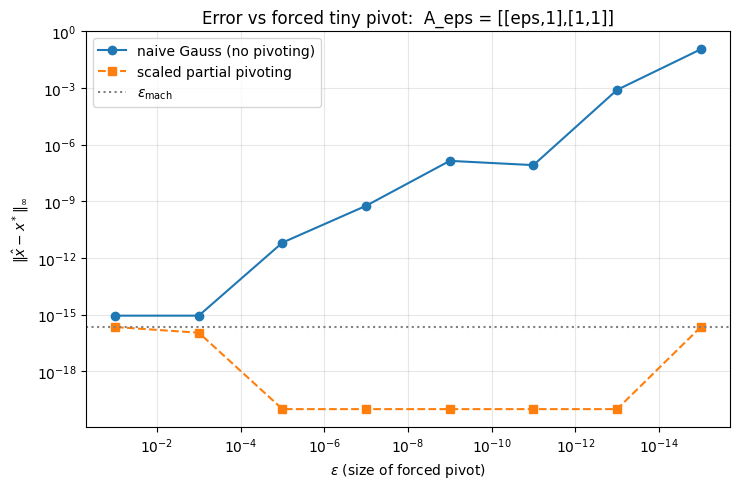

In [5]:
# === Visualization for Case B (the most striking) ===
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(df_B["eps"], df_B["naive err"].clip(lower=1e-20), "o-", label="naive Gauss (no pivoting)")
ax.loglog(df_B["eps"], df_B["spp   err"].clip(lower=1e-20), "s--", label="scaled partial pivoting")
eps_mach = np.finfo(float).eps
ax.axhline(eps_mach, color="gray", ls=":", label=r"$\varepsilon_{\mathrm{mach}}$")
ax.set_xlabel(r"$\varepsilon$ (size of forced pivot)")
ax.set_ylabel(r"$\|\hat{x} - x^*\|_\infty$")
ax.set_title("Error vs forced tiny pivot:  A_eps = [[eps,1],[1,1]]")
ax.invert_xaxis()
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

### Case A — 잘 조건된 random matrix
- naïve, SPP, NumPy 셋 다 잔차/오차가 $\sim n \varepsilon_{\text{mach}}$ 로 거의 동일.
- random matrix 의 조건수가 $\mathcal{O}(n)$ 수준이라 *어떤 알고리즘으로 풀어도* 충분히 정확.
- **즉 well-conditioned 시스템에서는 pivoting 의 효과가 거의 드러나지 않는다.**

### Case B — 작은 피봇이 강제되는 2$\times$2
- $A_\varepsilon = \begin{pmatrix}\varepsilon & 1 \\ 1 & 1\end{pmatrix}$ 의 naïve 첫 피봇은 $\varepsilon$.
- $m_{21} = 1/\varepsilon$ 이 거대해지면서 행 갱신 $1 - 1/\varepsilon \cdot 1$ 에서 **catastrophic cancellation** 발생.
- $\varepsilon$ 이 $10^{-15}$ 로 가면 naïve 오차가 $\mathcal{O}(1)$ 수준으로 **완전 실패**.
- SPP 는 $r_{1,1} = \varepsilon / 1 \ll 1/1 = r_{2,1}$ 를 보고 **두 번째 행을 피봇으로** 골라
  $\varepsilon$ 과 무관하게 정확.

### Case C — 한 행에 큰 entry 가 있어 스케일이 큰 케이스
- 행 0 은 $s_0 = 10^6$, 행 0 의 0열 항 ratio $r_{0,0} = 10^{-10}/10^6 = 10^{-16}$ — SPP 가 즉시 다른 행을 선택.
- naïve 는 $10^{-10}$ 을 피봇으로 강행해 $m_{i0} \sim 10^{10}$, 오차가 잔차보다 훨씬 큼.

### 결론
> **scaled partial pivoting 의 가치는 "어떤 시스템에서 무너지지 않는가" 로 드러난다.**
> 잘 조건된 random matrix 처럼 *문제 자체가 좋으면* 누구도 안 무너지고, *대각 위치에 작은 항이 오는* 문제에서야 비로소 두 배 빠르고 두 배 정확해진다.

### 다음 (Problem 2)
*조건수* 와 잔차의 관계를 좀 더 본격적으로: $\kappa(A)$ 를 의도적으로 조절해 가며 오차 상한
$\|\hat{\mathbf{x}}-\mathbf{x}^*\| \le \kappa(A) \cdot \|r\| / \|b\|$ 을 실측한다.
